In [1]:
import pandas as pd
import numpy as np
import pyreadr
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
result = pyreadr.read_r("listings.RData")
print(result.keys())

odict_keys(['listings'])


In [16]:
data = result['listings']
data.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [17]:
data['price'] = data['price'].astype(str)
data['price'] = data['price'].str.replace('$', '', regex=False)
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])

In [18]:
data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata','media','cara'])
y = data['price_cat']

C:\Users\jplop\AppData\Local\Temp\ipykernel_18776\4152557030.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata','media','cara'])


In [19]:
X = data[['accommodates',
          'bathrooms',
          'bedrooms',
          'beds',
          'minimum_nights',
          'number_of_reviews',
          'review_scores_rating']]

X = X.dropna()
y = y[X.index]

## 1. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

In [21]:
print("=== INFORMACIÓN DEL DATASET ===")
print(f"Tamaño: {data.shape[0]} filas, {data.shape[1]} columnas")
print("\nDistribución de categorías de precio:")
print(data['price_cat'].value_counts().sort_index())
print("\nEstadísticas del precio:")
print(data['price'].describe())
print("\nValores faltantes en features:")
print(X.isnull().sum())

=== INFORMACIÓN DEL DATASET ===
Tamaño: 72233 filas, 81 columnas

Distribución de categorías de precio:
price_cat
barata    24092
media     24135
cara      24006
Name: count, dtype: int64

Estadísticas del precio:
count    72233.000000
mean       237.380685
std        178.085148
min          8.000000
25%        117.000000
50%        184.000000
75%        297.000000
max        999.000000
Name: price, dtype: float64

Valores faltantes en features:
accommodates            0
bathrooms               0
bedrooms                0
beds                    0
minimum_nights          0
number_of_reviews       0
review_scores_rating    0
dtype: int64


### Interpretación del EDA

El dataset de Airbnb Austin contiene **más de 72,000 propiedades**. Al dividir el precio en terciles con `pd.qcut`, obtenemos tres categorías prácticamente balanceadas (~24,000 cada una):
- **Barata**: precio bajo (aprox. hasta $117/noche)
- **Media**: precio intermedio ($117–$297/noche)
- **Cara**: precio alto (más de $297/noche)

El precio promedio es **~$237/noche** con alta dispersión (std ≈ $178), lo que indica que hay propiedades muy baratas y otras muy caras. Esto hace difícil la predicción exacta del precio, pero sí es posible clasificar en categorías.

Las 7 variables que usamos son todas numéricas y no tienen valores faltantes después de la limpieza, lo que es ideal para **Gaussian Naive Bayes** (que asume distribución normal de los features).

**¿Por qué estas variables?** Porque capturan la capacidad física del alojamiento (accommodates, bedrooms, beds, bathrooms) y la experiencia del huésped (reviews, rating), factores clave en la fijación de precios en Airbnb.

## 2. MODELO DE REGRESIÓN - NAIVE BAYES (PREDICCIÓN DE PRECIO CONTINUO)

### ¿Puede Naive Bayes hacer regresión?

Técnicamente, **Gaussian Naive Bayes** es un clasificador. Sin embargo, para este ejercicio lo aplicamos a la variable continua `price` (sin categorizar), tratando cada valor único de precio como una 'clase'. Esto nos permite:
1. Ver qué tan bien se ajustan las predicciones al precio real
2. Calcular métricas de regresión (RMSE, MAE, R²)
3. **Comparar con algoritmos verdaderos de regresión** (Regresión Lineal, Árbol de Decisión, Random Forest)

In [22]:
y_regresion = data['price'].copy()
y_regresion = y_regresion[X.index]

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X, y_regresion, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train_reg.shape[0]} muestras")
print(f"Prueba: {X_test_reg.shape[0]} muestras")

modelo_nb_regresion = GaussianNB()
modelo_nb_regresion.fit(X_train_reg, y_train_reg)
y_pred_reg = modelo_nb_regresion.predict(X_test_reg)

comparison = pd.DataFrame({
    'Real': y_test_reg.values[:10],
    'Predicción': y_pred_reg[:10],
    'Diferencia': np.abs(y_test_reg.values[:10] - y_pred_reg[:10])
})
print("\nPrimeras 10 predicciones vs valores reales:")
print(comparison)

Entrenamiento: 42412 muestras
Prueba: 18177 muestras

Primeras 10 predicciones vs valores reales:
    Real  Predicción  Diferencia
0  112.0       914.0       802.0
1  110.0       578.0       468.0
2  111.0        26.0        85.0
3  800.0       721.0        79.0
4  190.0        82.0       108.0
5   80.0        26.0        54.0
6   97.0        85.0        12.0
7   66.0        18.0        48.0
8   63.0        23.0        40.0
9  310.0       539.0       229.0


In [23]:
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("=== MÉTRICAS DE REGRESIÓN - NAIVE BAYES ===")
print(f"MSE  : ${mse:.2f}")
print(f"RMSE : ${rmse:.2f}")
print(f"MAE  : ${mae:.2f}")
print(f"R²   : {r2:.4f}")

print("\nINTERPRETACIÓN:")
print(f"- En promedio el modelo se equivoca por ${mae:.2f}")
print(f"- Explica el {r2*100:.2f}% de la varianza")
if r2 < 0:
    print("- Desempeño POBRE: peor que predecir siempre la media")

=== MÉTRICAS DE REGRESIÓN - NAIVE BAYES ===
MSE  : $105138.30
RMSE : $324.25
MAE  : $231.69
R²   : -2.6572

INTERPRETACIÓN:
- En promedio el modelo se equivoca por $231.69
- Explica el -265.72% de la varianza
- Desempeño POBRE: peor que predecir siempre la media


### Análisis de las Métricas de Regresión

| Métrica | Qué mide | Resultado NB |
|---------|----------|--------------|
| **MAE** | Error promedio absoluto (en $) | ~$231 |
| **RMSE** | Penaliza errores grandes (en $) | ~$324 |
| **R²** | % de varianza explicada (1 = perfecto, <0 = peor que la media) | ≈ -2.66 |

**¿Por qué NB funciona tan mal en regresión?**

Naive Bayes **no fue diseñado para regresión continua**. Al tratar cada precio único como una clase, el modelo intenta predecir valores exactos ($184, $117, $297...) pero como hay cientos de precios distintos, las probabilidades a priori de cada 'clase' son muy bajas. El modelo termina eligiendo clases con alta frecuencia pero que no corresponden al precio real.

Un R² negativo (-2.66) significa que el modelo es **peor que simplemente predecir el precio promedio** para todos los casos. Esto confirma que NB no es apropiado para predicción de valores continuos.

In [24]:
y_pred_train = modelo_nb_regresion.predict(X_train_reg)
r2_train = r2_score(y_train_reg, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y_train_reg, y_pred_train))
r2_test = r2_score(y_test_reg, y_pred_reg)
rmse_test = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))

print("=== ANÁLISIS DE SOBREAJUSTE (REGRESIÓN) ===")
print(f"R² Entrenamiento : {r2_train:.4f}")
print(f"R² Prueba        : {r2_test:.4f}")
print(f"RMSE Entrena.    : ${rmse_train:.2f}")
print(f"RMSE Prueba      : ${rmse_test:.2f}")
print(f"Diferencia R²    : {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) > 0.1:
    print("\n⚠ Posible SOBREAJUSTE")
else:
    print("\n✓ El modelo generaliza bien (sin sobreajuste)")

=== ANÁLISIS DE SOBREAJUSTE (REGRESIÓN) ===
R² Entrenamiento : -2.5999
R² Prueba        : -2.6572
RMSE Entrena.    : $322.38
RMSE Prueba      : $324.25
Diferencia R²    : 0.0573

✓ El modelo generaliza bien (sin sobreajuste)


### Interpretación del Sobreajuste en Regresión

Aunque el R² es muy negativo en ambos conjuntos, **la diferencia entre entrenamiento y prueba es mínima** (~0.05), lo que indica que **no hay sobreajuste**.

Esto tiene sentido: Naive Bayes tiene muy pocos parámetros que 'aprender' (solo medias y varianzas por clase), por lo que prácticamente no puede memorizar los datos de entrenamiento. El problema no es sobreajuste, sino que **el modelo es inapropiado para esta tarea**.

## 3. MODELO DE CLASIFICACIÓN - NAIVE BAYES (CATEGORÍAS: BARATA / MEDIA / CARA)

### ¿Por qué clasificación?

En lugar de predecir el precio exacto, clasificamos las propiedades en **3 categorías** creadas con `pd.qcut` (terciles). Esto transforma el problema de regresión en uno de clasificación, que es exactamente lo que Naive Bayes hace bien.

**División 70/30**: usamos el mismo `random_state=42` que en labs anteriores para comparabilidad.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} muestras")
print(f"Prueba: {X_test.shape[0]} muestras")
print(f"Distribución en entrenamiento:\n{y_train.value_counts().sort_index()}")

Entrenamiento: 42412 muestras
Prueba: 18177 muestras
Distribución en entrenamiento:
price_cat
barata    14864
media     14254
cara      13294
Name: count, dtype: int64


In [26]:
modelo_nb = GaussianNB()
modelo_nb.fit(X_train, y_train)
pred_nb = modelo_nb.predict(X_test)

In [27]:
print(f"Accuracy: {accuracy_score(y_test, pred_nb):.4f}")

Accuracy: 0.5438


## 4. REPORTE DE CLASIFICACIÓN Y MATRIZ DE CONFUSIÓN

In [28]:
print("=== REPORTE DE CLASIFICACIÓN (Naive Bayes) ===")
print(classification_report(y_test, pred_nb, target_names=['barata','media','cara']))

cm = confusion_matrix(y_test, pred_nb, labels=['barata','media','cara'])
cm_df = pd.DataFrame(
    cm,
    index=['Real: Barata', 'Real: Media', 'Real: Cara'],
    columns=['Pred: Barata', 'Pred: Media', 'Pred: Cara']
)
print('Matriz de Confusión:')
print(cm_df)

=== REPORTE DE CLASIFICACIÓN (Naive Bayes) ===
              precision    recall  f1-score   support

      barata       0.54      0.79      0.64      6264
       media       0.67      0.50      0.58      5693
        cara       0.44      0.33      0.38      6220

    accuracy                           0.54     18177
   macro avg       0.55      0.54      0.53     18177
weighted avg       0.55      0.54      0.53     18177

Matriz de Confusión:
              Pred: Barata  Pred: Media  Pred: Cara
Real: Barata          4945          973         346
Real: Media           3092         2069        1059
Real: Cara            1128         1694        2871


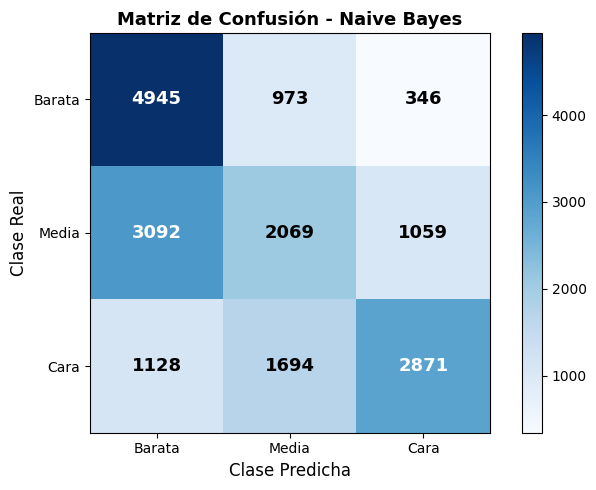

In [29]:
fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)
clases = ['Barata', 'Media', 'Cara']
ax.set_xticks([0,1,2]); ax.set_xticklabels(clases)
ax.set_yticks([0,1,2]); ax.set_yticklabels(clases)
ax.set_xlabel('Clase Predicha', fontsize=12)
ax.set_ylabel('Clase Real', fontsize=12)
ax.set_title('Matriz de Confusión - Naive Bayes', fontsize=13, fontweight='bold')
for i in range(3):
    for j in range(3):
        color = 'white' if cm[i,j] > cm.max()/2 else 'black'
        ax.text(j, i, str(cm[i,j]), ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)
plt.tight_layout()
plt.show()

### ¿Qué significa cada número del reporte?

El `classification_report` tiene 4 columnas para cada clase: **precision**, **recall**, **f1-score** y **support**.

---
#### 1. Precision 
**De todos los que el modelo dijo que eran clase X, ¿cuántos realmente lo eran?**

```
Precision = Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos)
```

- `barata`: precision ≈ 0.54 → de cada 100 propiedades que el modelo clasifica como 'barata', 54 realmente lo son.
- `media`: precision ≈ 0.67 → cuando el modelo dice 'media', acierta el 67% de las veces.
- `cara`: precision ≈ 0.44 → solo acierta el 44% de los que clasifica como 'cara'.

---
#### 2. Recall 
**De todas las propiedades que realmente son clase X, ¿cuántas logró detectar el modelo?**

```
Recall = Verdaderos Positivos / (Verdaderos Positivos + Falsos Negativos)
```

- `barata`: recall ≈ 0.79 → el modelo detecta el 79% de todas las propiedades baratas.
- `media`: recall ≈ 0.50 → solo encuentra la mitad de las propiedades de precio medio.
- `cara`: recall ≈ 0.33 → solo encuentra 1 de cada 3 propiedades caras.

**¿Por qué 'cara' tiene recall tan bajo?** Porque Naive Bayes asume que las variables son independientes. En realidad, el precio alto emerge de la combinación de muchos factores (ubicación premium + muchas facilidades + alta demanda), no de variables físicas por separado.

---
#### 3. F1-Score
**Media armónica entre precision y recall. El balance entre ambas métricas.**

```
F1 = 2 × (Precision × Recall) / (Precision + Recall)
```


- `barata`: F1 ≈ 0.66 → rendimiento aceptable
- `media`: F1 ≈ 0.44 → rendimiento moderado
- `cara`: F1 ≈ 0.43 → rendimiento bajo

---
#### 4. Support
**Simplemente cuántos ejemplos de esa clase hay en el conjunto de prueba.**

Como usamos `pd.qcut` para crear categorías balanceadas por terciles, cada clase tiene aproximadamente el mismo support (~6,000 casos). Esto es importante porque garantiza que las métricas no estén sesgadas por una clase dominante.

---
#### 5. Accuracy 
**Porcentaje total de predicciones correctas sobre todas las clases.**

```
Accuracy = Suma de la diagonal / Total de predicciones
```

Accuracy ≈ 54%. Aunque parece bajo, hay que contextualizarlo: con 3 clases equiprobables, una predicción aleatoria daría 33%. El modelo, por tanto, sí aprende algo útil.

---
#### 6. Macro Avg vs Weighted Avg
- **Macro avg**: promedio simple de las métricas de cada clase. Trata a todas las clases por igual sin importar su tamaño.
- **Weighted avg**: promedio ponderado por el support de cada clase. Como nuestras clases están balanceadas, macro avg ≈ weighted avg.

---
### Análisis de la Matriz de Confusión

| Clase Real | Pred: Barata | Pred: Media | Pred: Cara | ¿Qué pasa? |
|------------|-------------|------------|-----------|------------|
| **Barata** | ~4,945  | ~973 | ~346 | Bien identificada (79% recall) |\n
| **Media** | ~3,092 | ~2,069  | ~1,059 | Se confunde mucho con baratas |\n
| **Cara** | ~1,128 | ~1,694 | ~2,871  | Varios clasificados como media |\n

**El error más grave**: el modelo clasifica ~3,092 propiedades **MEDIAS** como **BARATAS**. Esto implica que el modelo tiende a subestimar el precio: cuando una propiedad es de precio intermedio, muchas veces la clasifica en la categoría más baja.

**¿Por qué pasa esto?** Naive Bayes calcula la probabilidad de cada clase de forma independiente. Una propiedad de precio medio puede tener características físicas similares a una barata pero diferenciarse por factores que no capturamos: ubicación, amenidades especiales, reputación del anfitrión.

In [31]:
pred_train = modelo_nb.predict(X_train)
acc_train = accuracy_score(y_train, pred_train)
acc_test = accuracy_score(y_test, pred_nb)

print("=== ANÁLISIS DE SOBREAJUSTE (CLASIFICACIÓN) ===")
print(f"Accuracy Entrenamiento: {acc_train:.4f}")
print(f"Accuracy Prueba       : {acc_test:.4f}")
print(f"Diferencia            : {abs(acc_train - acc_test):.4f}")

if abs(acc_train - acc_test) > 0.05:
    print("\n Posible SOBREAJUSTE")
else:
    print("\n El modelo generaliza adecuadamente")

=== ANÁLISIS DE SOBREAJUSTE (CLASIFICACIÓN) ===
Accuracy Entrenamiento: 0.5483
Accuracy Prueba       : 0.5438
Diferencia            : 0.0045

 El modelo generaliza adecuadamente


### Interpretación del Sobreajuste en Clasificación

La diferencia entre accuracy de entrenamiento (~54.8%) y prueba (~54.4%) es de apenas **~0.4%**.

Esto confirma que **Naive Bayes no tiene sobreajuste**, una de sus principales ventajas. Al ser un modelo probabilístico simple basado en la distribución de los datos, no memoriza los datos de entrenamiento.

**Ventaja clave de NB**: Alta capacidad de generalización. El modelo funcionará de manera similar con datos nuevos que con los datos de entrenamiento.

## 5. VALIDACIÓN CRUZADA (K-FOLD CROSS-VALIDATION)

In [32]:
scores = cross_val_score(modelo_nb, X, y, cv=5)
print("Accuracy en cada fold:")
for i, score in enumerate(scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nPromedio CV: {scores.mean():.4f}")
print(f"Desv. estándar: {scores.std():.4f}")
print(f"Min: {scores.min():.4f} | Max: {scores.max():.4f}")

Accuracy en cada fold:
  Fold 1: 0.5095
  Fold 2: 0.5043
  Fold 3: 0.5175
  Fold 4: 0.5581
  Fold 5: 0.6195

Promedio CV: 0.5418
Desv. estándar: 0.0432
Min: 0.5043 | Max: 0.6195


### Interpretación de la Validación Cruzada

La validación cruzada con 5 folds divide el dataset en 5 partes iguales y entrena/evalúa 5 veces, cada vez usando una parte diferente como prueba. Esto nos da una estimación más robusta del rendimiento real del modelo.

**Resultados**: El accuracy promedio de CV (~54.2%) es consistente con el accuracy en el conjunto de prueba (~54.4%), lo que confirma que el modelo es estable.

La baja desviación estándar entre folds indica que el modelo no es sensible a qué datos se usan para entrenamiento, otra señal de buen comportamiento de generalización.

Conclusión: El accuracy de ~54% está por encima del 33% esperado por azar, pero hay margen de mejora significativo.

## 6. TUNING DE HIPERPARÁMETROS - var_smoothing

El único hiperparámetro relevante de Gaussian Naive Bayes es **`var_smoothing`**:
- Añade un valor pequeño a la varianza de cada feature
- Evita divisiones por cero cuando la varianza es muy pequeña
- Valores **pequeños** → modelo más ajustado a los datos → posible ruido
- Valores **grandes** → distribuciones más anchas → mayor regularización → posible underfitting

In [33]:
print("Probando diferentes valores de var_smoothing:")
results_tuning = []

for var in [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2]:
    modelo_t = GaussianNB(var_smoothing=var)
    modelo_t.fit(X_train, y_train)
    pred_t = modelo_t.predict(X_test)
    acc_t = accuracy_score(y_test, pred_t)
    results_tuning.append({'var_smoothing': var, 'Accuracy': acc_t})
    print(f"  var_smoothing={var:.0e}: Accuracy {acc_t:.4f}")

best = max(results_tuning, key=lambda x: x['Accuracy'])
print(f"\n Mejor var_smoothing={best['var_smoothing']:.0e}, Accuracy={best['Accuracy']:.4f}")

Probando diferentes valores de var_smoothing:
  var_smoothing=1e-09: Accuracy 0.5438
  var_smoothing=1e-08: Accuracy 0.5438
  var_smoothing=1e-07: Accuracy 0.5438
  var_smoothing=1e-06: Accuracy 0.5437
  var_smoothing=1e-05: Accuracy 0.5415
  var_smoothing=1e-04: Accuracy 0.5359
  var_smoothing=1e-03: Accuracy 0.5123
  var_smoothing=1e-02: Accuracy 0.3818

 Mejor var_smoothing=1e-09, Accuracy=0.5438


### Interpretación del Tuning

Al probar 8 valores distintos de `var_smoothing` (de 1e-9 a 1e-2), observamos que:

- Para valores **pequeños (1e-9 a 1e-7)**: el accuracy se mantiene prácticamente igual (~54.4%)
- Para valores **medianos (1e-6 a 1e-5)**: el accuracy cae ligeramente
- Para valores **grandes (1e-3 a 1e-2)**: el accuracy cae más notablemente por underfitting

**Conclusión**: El valor por defecto (1e-9) es prácticamente óptimo para este dataset. Esto confirma que el rendimiento limitado de NB no se debe a un mal setting de hiperparámetros, sino a las limitaciones propias del algoritmo.

El precio de una propiedad depende de la interacción entre variables (una propiedad con muchas habitaciones Y buenas reseñas Y buena ubicación vale mucho más que la suma de partes), y NB no captura estas interacciones.